# Script for Coherence Change Detection using Sentinel-1 data and SNAP

*******************************************************************************************

## Disclaimer
Disclaimer: This product has been derived automatically without validation data. All geographic information has limitations due to the scale, resolution, date and interpretation of the original source materials. No liability concerning the content or the use thereof is assumed by the producer.

Script created by: Geospatial Operations Support Team, The World Bank, March 2021.
Updated: November 2025
*******************************************************************************************

# Coherence Change Detection principle
Coherent Change Detection, also known as CCD, is an intelligence gathering process in which two  time-lapsed high-resolution satellite radar images of one geographic area on the surface of Earth, or other planets, are compared in order to detect and measure changes to that area.

Changes included into the coherence measurement can be considered as:
* Geometric changes: changes due to slighly different incident angle
* Changes occurred between the two SAR acquisitions involved in the computation
* Noise: noise signal or noise introduced by the different processes.

Such comparisons are done using an algorithm that takes into account both the geographic area and mission parameters. The satellite-based imaging technology used most often to execute this process is known as Synthetic Aperture Radar, or SAR, which has led to CCD also often being called SAR Coherent Change Detection. Although radar-based intelligence gathering is a Measurement and Signals Intelligence (MASINT) category, the use of CCD products can be paired with Geospatial Intelligence (GEOINT) to visually depict physical features on the Earth.

A good example is found in this article which applies this principle, titled "*Coherence Change-Detection with Sentinel-1 for Natural and Anthropogenic Disaster Monitoring in Urban Areas*" (https://doi.org/10.3390/rs10071026 )

## Importing / installing needed libraries

In [1]:
#@title libraries for input data
try:
  import ipywidgets as widgets
except:
  import ipywidgets as widgets
import zipfile
import os
import glob
try:
  import fiona
except:
  !pip install fiona
  import fiona
from shapely.geometry import shape


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 77.0 MB/s eta 0:00:00


## Defining parameters for data discovering / processing

In [2]:
#@title Upload shapefile over AoI (zip format)

myupload = widgets.FileUpload(
    accept= '.zip',
    multiple=False
)
myupload

FileUpload(value={}, accept='.zip', description='Upload')

In [3]:
#@title Select start date from the calendar
startdate=widgets.DatePicker(
    description='Start Date',
    disabled=False
)
startdate

DatePicker(value=None, description='Start Date')

In [4]:
#@title Select stop date as day after event
stopdate=widgets.DatePicker(
    description='Event Date',
    disabled=False
)
stopdate

DatePicker(value=None, description='Event Date')

# Satellite data search and download

In [5]:
#@title Obtaining footprint from shapefile
## Discovering selected file
print(myupload.value)
uploaded_filename = next(iter(myupload.value))
content = myupload.value[uploaded_filename]['content']
filename=myupload.metadata[0]['name']
print('#############################################')
print('Selected file: '+filename)
# Uploading file in notebook / server
print('#############################################')
print('Uploading file: '+filename)
with open(filename, 'wb') as f: f.write(content)

## Unzipping file
print('#############################################')
print('Unzipping file: '+filename)
with zipfile.ZipFile(filename, 'r') as zip_ref:
    zip_ref.extractall(os.getcwd())

## Finding file and reading coordinates
print('#############################################')
print('Extracting Bounding Box from shapefile')
shpfile=glob.glob(os.path.join(os.getcwd(),'*.shp'))
print(shpfile)
c = fiona.open(shpfile[0])
#print(c.bounds)
lonmin,latmin,lonmax,latmax=c.bounds
#print(lonmin)
#print(latmin)
footprint='POLYGON(('+str(lonmin)+' '+str(latmin)+','+str(lonmin)+' '+str(latmax)+','+str(lonmax)+' '+str(latmax)+','+str(lonmax)+' '+str(latmin)+','+str(lonmin)+' '+str(latmin)+'))'
print('Shapefile footprint')
print(footprint)
########
# Selected data
starttime=startdate.value.strftime('%Y-%m-%d')
stoptime=stopdate.value.strftime('%Y-%m-%d')
print('#########################################')
print('Start date: '+starttime)
print('Stop date: '+stoptime)
acdate=(starttime,stoptime)

{'Beirut_AOI.zip': {'metadata': {'name': 'Beirut_AOI.zip', 'type': 'application/zip', 'size': 1033, 'lastModified': 1743369894023}, 'content': b'PK\x03\x04\n\x00\x00\x00\x00\x00\x0f\xa2\xb1RP<\x81\x0e\x05\x00\x00\x00\x05\x00\x00\x00\x0e\x00\x00\x00Beirut_AOI.cpgUTF-8PK\x03\x04\x14\x00\x00\x00\x08\x00i\xa2\xb1R\xb6\x90\xff\xe5\x1e\x00\x00\x00M\x00\x00\x00\x0e\x00\x00\x00Beirut_AOI.dbfc\xaed\x15dd``pd\xe0f\xc0\x062S\xe0L?\x10\xc1\x85&\xcf\xab\x00\x07\x86R\x00PK\x03\x04\x14\x00\x00\x00\x08\x00\x0f\xa2\xb1RU\x7fC\xafy\x00\x00\x00\x91\x00\x00\x00\x0e\x00\x00\x00Beirut_AOI.prjM\xcc\xb1\x0e\xc2 \x14\x85\xe1wa&\x04\xee\x85\x02\xa3\x11\x82\x0c\xd8\xa6\xb4q \xa4\x83!\xea\xe2\xe0\xe2\xebK\\\xda\xe5\x0c_r\xfe\xe0\xc7p\xce\x85\xf4\xd9n!o\xc2\x1aI\xa8;-k*\xc4\x1d(O\x17?\x8f\xd1\x15\xb2\xdb\x80\xda\x08\xd4\x8cS\xb0\x86\x81\xd2\x00\xa8\x06\xac\x95NsL>\xf5\xec\xa7\xb5\xf7\xf7u\x7f\x12\xca\x19\xaft\xbd\xc6\xa5w\xdb\xa3\xfb\x9f\x84\x96\n\xc1\x82\x12\xd6J\xec\xd7\x1fPK\x03\x04\x14\x00\x00\x00\x08\x00i\xa2

## Search Satellite data

In [7]:
#@title Selecting Relative Orbit
print('Introduce track (relative orbit) number')
print('For Beirut use track 94')
track=input()

Introduce track (relative orbit) number
For Beirut use track 94
94


# Installing phidown to download data from Copernicus Data Space Ecosystem (CDSE)

In [13]:
#@ pip install phidown
!pip install phidown folium fiona

In [14]:
"""
Import Required Libraries

Import the CopernicusDataSearcher class from phidown for burst searching.

Note: If you get an error about 'burst_mode' parameter not found, please:
1. Restart the kernel (Kernel > Restart Kernel)
2. Re-run this cell
This ensures the latest phidown version with burst mode support is loaded.
"""
from phidown.search import CopernicusDataSearcher
import pandas as pd

# Set pandas display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

In [26]:
"""
Advanced Multi-Parameter Search

Demonstrate combining multiple burst-specific filters for precise queries.
This example searches for a specific burst ID with additional constraints.
"""
searcher = CopernicusDataSearcher()

searcher.query_by_filter(
    burst_mode=False,
    aoi_wkt=footprint,
    collection_name='SENTINEL-1',
    product_type='SLC',
    #orbit_direction='DESCENDING',
    operational_mode='IW',
    polarisation_channels='VV',
    #platform_serial_identifier='A',  # Sentinel-1A
    start_date=starttime,
    end_date=stoptime,
    top=20,
    count=True,
    attributes={'processingLevel':'LEVEL1',
                'operationalMode': 'IW',
                'relativeOrbitNumber': int(track)
    }
)

print(f'Query URL: {searcher._build_query()}\n')

# Execute and display
df = searcher.execute_query()
print(f'Found {len(df)} bursts matching all criteria')
print(f'Total available: {searcher.num_results}')
searcher.display_results(top_n=10)


Query URL: https://catalogue.dataspace.copernicus.eu/odata/v1/Products?$filter=(Collection/Name eq 'SENTINEL-1') and Attributes/OData.CSC.StringAttribute/any(att:att/Name eq 'productType' and att/OData.CSC.StringAttribute/Value eq 'SLC') and OData.CSC.Intersects(area=geography'SRID=4326;POLYGON((35.46377161543615 33.85862863984625, 35.46377161543615 33.91954002272944, 35.58696061782795 33.91954002272944, 35.58696061782795 33.85862863984625, 35.46377161543615 33.85862863984625))') and ContentDate/Start ge 2020-07-22 and ContentDate/Start lt 2020-08-06 and Attributes/OData.CSC.StringAttribute/any(att:att/Name eq 'processingLevel' and att/OData.CSC.StringAttribute/Value eq 'LEVEL1') and Attributes/OData.CSC.StringAttribute/any(att:att/Name eq 'operationalMode' and att/OData.CSC.StringAttribute/Value eq 'IW') and Attributes/OData.CSC.IntegerAttribute/any(att:att/Name eq 'relativeOrbitNumber' and att/OData.CSC.IntegerAttribute/Value eq 94)&$orderby=ContentDate/Start desc&$top=20&$expand=Att

,Id,Name,S3Path,GeoFootprint,OriginDate,Attributes
0,61e178e7-44c3-5ccd-9f36-b2f41e44e496,S1A_IW_SLC__1SDV_20200805T034334_20200805T0344...,/eodata/Sentinel-1/SAR/SLC/2020/08/05/S1A_IW_S...,"{'type': 'MultiPolygon', 'coordinates': [[[[35...",2020-08-05 08:04:23,"[{'@odata.type': '#OData.CSC.StringAttribute',..."
1,b1c000de-43a3-555f-bd5e-8c874dd4bb16,S1B_IW_SLC__1SDV_20200730T034254_20200730T0343...,/eodata/Sentinel-1/SAR/SLC/2020/07/30/S1B_IW_S...,"{'type': 'MultiPolygon', 'coordinates': [[[[35...",2020-07-30 07:52:32,"[{'@odata.type': '#OData.CSC.StringAttribute',..."
2,87ce457e-7dd7-58fd-9707-1a07b65b9298,S1A_IW_SLC__1SDV_20200724T034334_20200724T0344...,/eodata/Sentinel-1/SAR/SLC/2020/07/24/S1A_IW_S...,"{'type': 'MultiPolygon', 'coordinates': [[[[35...",2020-07-24 07:30:02,"[{'@odata.type': '#OData.CSC.StringAttribute',..."


In [21]:
#@title My credentials for data download
from pathlib import Path
from phidown.downloader import get_token
from getpass import getpass
user = getpass()
mypass=getpass()
access_token = get_token(username=user,password=mypass)

··········
··········


In [39]:
#@ Manage S3 Credentials: https://eodata-s3keysmanager.dataspace.copernicus.eu/panel/s3-credentials

string='''# filepath: the current working directory where phidown is launched
[default]
aws_access_key_id = checkyourkeyid
aws_secret_access_key = checkyouraccesskey
aws_region = eu-central-1
host_base = eodata.dataspace.copernicus.eu
host_bucket = eodata.dataspace.copernicus.eu
use_https = true
check_ssl_certificate = true'''
!echo '{string}'> .s5cfg

In [40]:
#@title Downloading SLC from search results

for filename in df['Name'].to_list():
  searcher.download_product(filename, config_file='./.s5cfg',output_dir=Path('./'))

Output directory: /content


Downloading: 100%|█████████▉| 7.43G/7.43G [01:03<00:00, 125MB/s] 


Output directory: /content


Downloading: 100%|█████████▉| 7.32G/7.32G [00:46<00:00, 170MB/s] 


Output directory: /content


Downloading: 100%|█████████▉| 7.43G/7.43G [00:44<00:00, 179MB/s] 


# Installing SNAP and dependencies

In [42]:
#@title Installing packages for S1 data processing
# Installing packages for S1 data processing
#!apt-get install -y libfftw3-dev libtiff5-dev gdal-bin gfortran libgfortran5 libgfortran3 jblas git
# Downloading the package
!wget https://download.esa.int/step/snap/13.0/installers/esa-snap_sentinel_linux-13.0.0.sh
# configuration of installation parameters for Sentinel-1 Toolbox only
!TBX=esa-snap_sentinel_linux-13.0.0.sh ; chmod +x $TBX ; echo -e "deleteAllSnapEngineDir\$Boolean=false\ndeleteOnlySnapDesktopDir\$Boolean=false\nexecuteLauncherWithPythonAction\$Boolean=false\nforcePython\$Boolean=false\npythonExecutable=/usr/bin/python\nsys.adminRights\$Boolean=true\nsys.component.RSTB\$Boolean=true\nsys.component.S1TBX\$Boolean=true\nsys.component.S2TBX\$Boolean=false\nsys.component.S3TBX\$Boolean=false\nsys.component.SNAP\$Boolean=true\nsys.installationDir="$PWD"/snap\nsys.languageId=en\nsys.programGroupDisabled\$Boolean=false\nsys.symlinkDir=/usr/local/bin" >$PWD/snap.varfile ; ./$TBX -q -varfile $PWD/snap.varfile
# Updating SNAP
#!$PWD/snap/bin/snap --nosplash --nogui --modules --update-all
# Configuring memory and parameters
!echo "-Xmx8G" > $PWD/snap/bin/gpt.vmoptions

#!cp /content/drive/My\ Drive/WB_Coherence/snap.properties $PWD/snap/bin/.

--2025-11-22 16:27:31--  https://download.esa.int/step/snap/13.0/installers/esa-snap_sentinel_linux-13.0.0.sh
Resolving download.esa.int (download.esa.int)... 151.101.2.132, 151.101.66.132, 151.101.130.132, ...
Connecting to download.esa.int (download.esa.int)|151.101.2.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1054450997 (1006M) [application/x-sh]
Saving to: ‘esa-snap_sentinel_linux-13.0.0.sh’

esa-snap_sentinel_l 100%[===================>]   1006M   108MB/s    in 12s     

2025-11-22 16:28:06 (85.9 MB/s) - ‘esa-snap_sentinel_linux-13.0.0.sh’ saved [1054450997/1054450997]

Unpacking JRE ...
Starting Installer ...
The installation directory has been set to /content/snap.
Extracting files ...
Finishing installation ...
OpenJDK 64-Bit Server VM warning: Options -Xverify:none and -noverify were deprecated in JDK 13 and will likely be removed in a future release.
Refreshing SNAP Supported Plugins
Refreshing SNAP Core
Refreshing SNAP Community Plugins
Ref

In [46]:
#@title configuring snap (I/II)
%%writefile ./snap/etc/snap.auxdata.properties
####################################################################################
# Configuration for the Auxdata paths
# All properties described here can also be passed to the VM as system
# properties using the standard Java
#   -D<property>=<value>
# syntax. In addition, it is possible to use macros of the form
#   ${<property>}
# within a value. Macros will expand to the value of the referred file property,
# system property, or environment variable.
####################################################################################

#AuxDataPath = c:\\AuxData2
demPath = ${AuxDataPath}/dem

DEM.aceDEMDataPath = ${demPath}/ACE_DEM/ACE
DEM.aceDEM_HTTP = http://step.esa.int/auxdata/dem/ACE30/
DEM.ace2_5MinDEMDataPath = ${demPath}/ACE2/5M_HEIGHTS
DEM.ace2_5MinDEM_HTTP = http://step.esa.int/auxdata/dem/ACE2/5M/
DEM.CDEM_HTTP = http://step.esa.int/auxdata/dem/cdem/
DEM.gtopo30DEMDataPath = ${demPath}/GTOPO30/dem
DEM.AsterDEMDataPath = ${demPath}/ASTER
DEM.Getasse30DEMDataPath = ${demPath}/GETASSE30
DEM.srtm3GeoTiffDEMDataPath = ${demPath}/SRTM_DEM/tiff
DEM.srtm3GeoTiffDEM_FTP = xftp.jrc.it
DEM.srtm3GeoTiffDEM_remotePath = /pub/srtmV4/tiff/
DEM.srtm3GeoTiffDEM_HTTP = http://srtm.csi.cgiar.org/SRT-ZIP/SRTM_V41/SRTM_Data_GeoTiff/
DEM.srtm1HgtDEM_HTTP = http://step.esa.int/auxdata/dem/SRTMGL1/
DEM.srtm1GridDEMDataPath =

landCoverPath = ${AuxDataPath}/LandCover
LandCover.glc2000DataPath = ${landCoverPath}/glc2000
LandCover.globcoverDataPath = ${landCoverPath}/globcover

OrbitFiles.dorisHTTP_vor_remotePath = http://step.esa.int/auxdata/orbits/Doris/vor
OrbitFiles.dorisVOROrbitPath = ${AuxDataPath}/Orbits/Doris/vor
OrbitFiles.dorisPOROrbitPath = ${AuxDataPath}/Orbits/Doris/por

OrbitFiles.delftEnvisatOrbitPath = ${AuxDataPath}/Orbits/Delft Precise Orbits/ODR.ENVISAT1/eigen-cg03c
OrbitFiles.delftERS1OrbitPath = ${AuxDataPath}/Orbits/Delft Precise Orbits/ODR.ERS-1/dgm-e04
OrbitFiles.delftERS2OrbitPath = ${AuxDataPath}/Orbits/Delft Precise Orbits/ODR.ERS-2/dgm-e04

OrbitFiles.delftFTP = dutlru2.lr.tudelft.nl
OrbitFiles.delftFTP_ENVISAT_precise_remotePath = /pub/orbits/ODR.ENVISAT1/eigen-cg03c/
OrbitFiles.delftFTP_ERS1_precise_remotePath = /pub/orbits/ODR.ERS-1/dgm-e04/
OrbitFiles.delftFTP_ERS2_precise_remotePath = /pub/orbits/ODR.ERS-2/dgm-e04/

OrbitFiles.prareHTTP_ERS1_remotePath = http://step.esa.int/auxdata/orbits/ers_precise_orb/ERS1
OrbitFiles.prareHTTP_ERS2_remotePath = http://step.esa.int/auxdata/orbits/ers_precise_orb/ERS2
OrbitFiles.prareERS1OrbitPath = ${AuxDataPath}/Orbits/ers_precise_orb/ERS1
OrbitFiles.prareERS2OrbitPath = ${AuxDataPath}/Orbits/ers_precise_orb/ERS2

OrbitFiles.sentinel1POEOrbitPath = ${AuxDataPath}/Orbits/Sentinel-1/POEORB
OrbitFiles.sentinel1RESOrbitPath = ${AuxDataPath}/Orbits/Sentinel-1/RESORB
OrbitFiles.sentinel1POEOrbit_remotePath = https://aux.sentinel1.eo.esa.int/POEORB
OrbitFiles.sentinel1RESOrbit_remotePath = https://aux.sentinel1.eo.esa.int/RESORB
AuxCal.Sentinel1.remotePath = http://step.esa.int/auxdata/auxcal/S1/
AuxCal.ENVISAT.remotePath = http://step.esa.int/auxdata/auxcal/ENVISAT/
AuxCal.ERS.remotePath = http://step.esa.int/auxdata/auxcal/ERS/


Overwriting ./snap/etc/snap.auxdata.properties


In [47]:
#@title configuring snap (II/II)
%%writefile ./snap/bin/snap.properties
# tileCache and tileSize jai properties affect graph processing and image rendering
# Tile cache size [Mb]
snap.jai.tileCacheSize=8196
# Default tile size in pixels
snap.jai.defaultTileSize=2048
# number of CPU cores used for image rendering and graph processing
# allow this to default to Runtime.getRuntime().availableProcessors()
#snap.parallelism = 8
# Enable or disable the prefetch of tiles. Default is true.
snap.jai.prefetchTiles=true

Overwriting ./snap/bin/snap.properties


# Manually define reference and secondary images
### 1. Define the reference image as the last previous to the event
### 2. Define the secondary images as the oldest previous to the event and the post event

In [54]:
# Define the reference image as the last previous to the event
reference=os.path.join(os.getcwd(),'S1B_IW_SLC__1SDV_20200730T034254_20200730T034321_022695_02B131_E8DD.SAFE')
# Define the secondary images as the oldest previous to the event and the post event
secondaries=[]
secondaries=[os.path.join(os.getcwd(),'S1A_IW_SLC__1SDV_20200724T034334_20200724T034401_033591_03E49D_96AA.SAFE')]
secondaries.append(os.path.join(os.getcwd(),'S1A_IW_SLC__1SDV_20200805T034334_20200805T034401_033766_03E9F9_52F6.SAFE'))
print('Reference image:'+reference)

Reference image:/content/S1B_IW_SLC__1SDV_20200730T034254_20200730T034321_022695_02B131_E8DD.SAFE


In [49]:
#@title Defining parameters for satellite data processing
# Sentinel-1 SLC images
import glob
import os
#images=sorted(glob.glob(os.path.join(os.getcwd(),'S1*zip')))
#reference=images[1]
#secondaries=[images[0],images[2]]

# Subswath
print('Select one subswath [IW1,IW2,IW3] (default IW1)')
IWs=input()
if IWs=="":
  IWs='IW1'
print('Selected subswath:'+IWs)
# polarisation
print('Select polarisation [VV,VH] (default VV)')
polarisation=input()
if polarisation=='':
  polarisation='VV'
print('Selected polarisation:'+polarisation)

print(footprint)

# Defining graphs to be employed (Graph xml includes all steps to run using SNAP in command line)
#graphxml='/content/drive/MyDrive/WB_Coherence/WB_coherence.xml'
#graphxml='/content/drive/MyDrive/WB_Coherence/Beirut/WB_Coh_TC_Subset2.xml'
outputifgfolder=os.getcwd()
graphxml=os.path.join(os.getcwd(),'WB_Coh_TC_Subset2.xml')
graph2run=os.path.join(os.getcwd(),'graph2run.xml')

Select one subswath [IW1,IW2,IW3] (default IW1)

Selected subswath:IW1
Select polarisation [VV,VH] (default VV)

Selected polarisation:VV
POLYGON((35.46377161543615 33.85862863984625,35.46377161543615 33.91954002272944,35.58696061782795 33.91954002272944,35.58696061782795 33.85862863984625,35.46377161543615 33.85862863984625))


In [50]:
#@title Defining SNAP processing graph to execute
%%writefile ./WB_Coh_TC_Subset2.xml
<graph id="Graph">
  <version>1.0</version>
  <node id="Read">
    <operator>Read</operator>
    <sources/>
    <parameters class="com.bc.ceres.binding.dom.XppDomElement">
      <file>REFERENCE</file>
    </parameters>
  </node>
  <node id="Read(2)">
    <operator>Read</operator>
    <sources/>
    <parameters class="com.bc.ceres.binding.dom.XppDomElement">
      <file>SECONDARY</file>
    </parameters>
  </node>
  <node id="TOPSAR-Split">
    <operator>TOPSAR-Split</operator>
    <sources>
      <sourceProduct refid="Read"/>
    </sources>
    <parameters class="com.bc.ceres.binding.dom.XppDomElement">
      <subswath>IWs</subswath>
      <selectedPolarisations>POLARISATION</selectedPolarisations>
      <firstBurstIndex>1</firstBurstIndex>
      <lastBurstIndex>9</lastBurstIndex>
      <wktAoi>POLYGON</wktAoi>
    </parameters>
  </node>
  <node id="TOPSAR-Split(2)">
    <operator>TOPSAR-Split</operator>
    <sources>
      <sourceProduct refid="Read(2)"/>
    </sources>
    <parameters class="com.bc.ceres.binding.dom.XppDomElement">
      <subswath>IWs</subswath>
      <selectedPolarisations>POLARISATION</selectedPolarisations>
      <firstBurstIndex>1</firstBurstIndex>
      <lastBurstIndex>10</lastBurstIndex>
      <wktAoi/>
    </parameters>
  </node>
  <node id="Apply-Orbit-File">
    <operator>Apply-Orbit-File</operator>
    <sources>
      <sourceProduct refid="TOPSAR-Split"/>
    </sources>
    <parameters class="com.bc.ceres.binding.dom.XppDomElement">
      <orbitType>Sentinel Restituted (Auto Download)</orbitType>
      <polyDegree>3</polyDegree>
      <continueOnFail>true</continueOnFail>
    </parameters>
  </node>
  <node id="Apply-Orbit-File(2)">
    <operator>Apply-Orbit-File</operator>
    <sources>
      <sourceProduct refid="TOPSAR-Split(2)"/>
    </sources>
    <parameters class="com.bc.ceres.binding.dom.XppDomElement">
      <orbitType>Sentinel Restituted (Auto Download)</orbitType>
      <polyDegree>3</polyDegree>
      <continueOnFail>true</continueOnFail>
    </parameters>
  </node>
  <node id="Back-Geocoding">
    <operator>Back-Geocoding</operator>
    <sources>
      <sourceProduct refid="Apply-Orbit-File"/>
      <sourceProduct.1 refid="Apply-Orbit-File(2)"/>
    </sources>
    <parameters class="com.bc.ceres.binding.dom.XppDomElement">
      <demName>SRTM 1Sec HGT</demName>
      <demResamplingMethod>BILINEAR_INTERPOLATION</demResamplingMethod>
      <externalDEMFile/>
      <externalDEMNoDataValue>0.0</externalDEMNoDataValue>
      <resamplingType>BISINC_21_POINT_INTERPOLATION</resamplingType>
      <maskOutAreaWithoutElevation>true</maskOutAreaWithoutElevation>
      <outputRangeAzimuthOffset>false</outputRangeAzimuthOffset>
      <outputDerampDemodPhase>false</outputDerampDemodPhase>
      <disableReramp>false</disableReramp>
    </parameters>
  </node>
  <node id="TOPSAR-Deburst">
    <operator>TOPSAR-Deburst</operator>
    <sources>
      <sourceProduct refid="Coherence"/>
    </sources>
    <parameters class="com.bc.ceres.binding.dom.XppDomElement">
      <selectedPolarisations>POLARISATION</selectedPolarisations>
    </parameters>
  </node>
  <node id="Coherence">
    <operator>Coherence</operator>
    <sources>
      <sourceProduct refid="Back-Geocoding"/>
    </sources>
    <parameters class="com.bc.ceres.binding.dom.XppDomElement">
      <cohWinAz>3</cohWinAz>
      <cohWinRg>10</cohWinRg>
      <subtractFlatEarthPhase>true</subtractFlatEarthPhase>
      <srpPolynomialDegree>5</srpPolynomialDegree>
      <srpNumberPoints>501</srpNumberPoints>
      <orbitDegree>3</orbitDegree>
      <squarePixel>true</squarePixel>
      <subtractTopographicPhase>true</subtractTopographicPhase>
      <demName>SRTM 1Sec HGT</demName>
      <externalDEMFile/>
      <externalDEMNoDataValue>0.0</externalDEMNoDataValue>
      <externalDEMApplyEGM>true</externalDEMApplyEGM>
      <tileExtensionPercent>100</tileExtensionPercent>
   <!--   <singleMaster>true</singleMaster> -->
    </parameters>
  </node>
  <node id="Terrain-Correction">
    <operator>Terrain-Correction</operator>
    <sources>
      <sourceProduct refid="TOPSAR-Deburst"/>
    </sources>
    <parameters class="com.bc.ceres.binding.dom.XppDomElement">
      <sourceBands/>
      <demName>SRTM 1Sec HGT</demName>
      <externalDEMFile/>
      <externalDEMNoDataValue>0.0</externalDEMNoDataValue>
      <externalDEMApplyEGM>true</externalDEMApplyEGM>
      <demResamplingMethod>BILINEAR_INTERPOLATION</demResamplingMethod>
      <imgResamplingMethod>BILINEAR_INTERPOLATION</imgResamplingMethod>
      <pixelSpacingInMeter>20.0</pixelSpacingInMeter>
      <pixelSpacingInDegree>1.796630568239043E-4</pixelSpacingInDegree>
      <mapProjection>GEOGCS[&quot;WGS84(DD)&quot;, &#xd;
  DATUM[&quot;WGS84&quot;, &#xd;
    SPHEROID[&quot;WGS84&quot;, 6378137.0, 298.257223563]], &#xd;
  PRIMEM[&quot;Greenwich&quot;, 0.0], &#xd;
  UNIT[&quot;degree&quot;, 0.017453292519943295], &#xd;
  AXIS[&quot;Geodetic longitude&quot;, EAST], &#xd;
  AXIS[&quot;Geodetic latitude&quot;, NORTH]]</mapProjection>
      <alignToStandardGrid>false</alignToStandardGrid>
      <standardGridOriginX>0.0</standardGridOriginX>
      <standardGridOriginY>0.0</standardGridOriginY>
      <nodataValueAtSea>true</nodataValueAtSea>
      <saveDEM>false</saveDEM>
      <saveLatLon>false</saveLatLon>
      <saveIncidenceAngleFromEllipsoid>false</saveIncidenceAngleFromEllipsoid>
      <saveLocalIncidenceAngle>false</saveLocalIncidenceAngle>
      <saveProjectedLocalIncidenceAngle>false</saveProjectedLocalIncidenceAngle>
      <saveSelectedSourceBand>true</saveSelectedSourceBand>
      <outputComplex>false</outputComplex>
      <applyRadiometricNormalization>false</applyRadiometricNormalization>
      <saveSigmaNought>false</saveSigmaNought>
      <saveGammaNought>false</saveGammaNought>
      <saveBetaNought>false</saveBetaNought>
      <incidenceAngleForSigma0>Use projected local incidence angle from DEM</incidenceAngleForSigma0>
      <incidenceAngleForGamma0>Use projected local incidence angle from DEM</incidenceAngleForGamma0>
      <auxFile>Latest Auxiliary File</auxFile>
      <externalAuxFile/>
    </parameters>
  </node>
  <node id="Subset">
    <operator>Subset</operator>
    <sources>
      <sourceProduct refid="Terrain-Correction"/>
    </sources>
    <parameters class="com.bc.ceres.binding.dom.XppDomElement">
      <sourceBands/>
      <region>0,0,5485,1857</region>
  <!--    <referenceBand/> -->
      <geoRegion>POLYGON</geoRegion>
      <subSamplingX>1</subSamplingX>
      <subSamplingY>1</subSamplingY>
      <fullSwath>false</fullSwath>
      <tiePointGridNames/>
      <copyMetadata>true</copyMetadata>
    </parameters>
  </node>
  <node id="Write">
    <operator>Write</operator>
    <sources>
      <sourceProduct refid="Subset"/>
    </sources>
    <parameters class="com.bc.ceres.binding.dom.XppDomElement">
      <file>OUTPUTIFGFOLDER/OUTPUTFILE</file>
      <formatName>GeoTIFF-BigTIFF</formatName>
    </parameters>
  </node>
  <applicationData id="Presentation">
    <Description/>
    <node id="Read">
      <displayPosition x="25.0" y="13.0"/>
    </node>
    <node id="Read(2)">
      <displayPosition x="28.0" y="229.0"/>
    </node>
    <node id="TOPSAR-Split">
      <displayPosition x="16.0" y="50.0"/>
    </node>
    <node id="TOPSAR-Split(2)">
      <displayPosition x="11.0" y="194.0"/>
    </node>
    <node id="Apply-Orbit-File">
      <displayPosition x="12.0" y="84.0"/>
    </node>
    <node id="Apply-Orbit-File(2)">
      <displayPosition x="6.0" y="160.0"/>
    </node>
    <node id="Back-Geocoding">
      <displayPosition x="116.0" y="123.0"/>
    </node>
    <node id="TOPSAR-Deburst">
      <displayPosition x="339.0" y="124.0"/>
    </node>
    <node id="Coherence">
      <displayPosition x="241.0" y="125.0"/>
    </node>
    <node id="Terrain-Correction">
      <displayPosition x="491.0" y="123.0"/>
    </node>
    <node id="Subset">
      <displayPosition x="678.0" y="126.0"/>
    </node>
    <node id="Write">
      <displayPosition x="804.0" y="124.0"/>
    </node>
  </applicationData>
</graph>

Writing ./WB_Coh_TC_Subset2.xml


# Sentinel Data processing

In [57]:
#@title Sentinel-1 data processing
import time
import os
import subprocess

for secondary in secondaries:
  startproc=time.perf_counter()
  outputname=os.path.basename(reference)[17:25]+'_'+os.path.basename(secondary)[17:25]+'_'+IWs+'.tif'
  print(outputname)
  if not os.path.exists(outputname) and not os.path.isfile(outputname):
    with open(graphxml, 'r') as file :
        filedata = file.read()
    # Replace the target string
    filedata = filedata.replace('REFERENCE',reference+'/manifest.safe')
    filedata = filedata.replace('SECONDARY', secondary+'/manifest.safe')
    filedata = filedata.replace('OUTPUTIFGFOLDER', outputifgfolder)
    filedata = filedata.replace('OUTPUTFILE',outputname)
    filedata = filedata.replace('POLYGON',footprint)
    filedata = filedata.replace('POLARISATION',polarisation)
    filedata = filedata.replace('IWs',IWs)
    # Write the file out again
    with open(graph2run, 'w') as file:
        file.write(filedata)
    args = [os.path.join(os.getcwd(),'snap','bin','gpt'), graph2run, '-c', '8G', '-q', '16']
    print(args)
    # Launch the processing
    #timeStarted = time.time()
    process = subprocess.Popen(args,shell=False,stdout=subprocess.PIPE,stderr=subprocess.STDOUT)

    # Poll process.stdout to show stdout live
    while True:
      output = process.stdout.readline()
      if process.poll() is not None:
        break
      if output:
        print (output.strip().decode('utf-8'))
    rc = process.poll()

    #timeDelta = time.time() - timeStarted                     # Get execution time.
    #print('Finished process in '+str(timeDelta)+' seconds.')

    stopproc=time.perf_counter()
    proctime=(stopproc-startproc)/60
    print('Processing completed in '+str(proctime)+' minutes')

20200730_20200724_IW1.tif
['/content/snap/bin/gpt', '/content/graph2run.xml', '-c', '8G', '-q', '16']
INFO: org.esa.snap.core.gpf.operators.tooladapter.ToolAdapterIO: Initializing external tool adapters
INFO: org.esa.snap.core.util.EngineVersionCheckActivator: Please check regularly for new updates for the best SNAP experience.
Executing processing graph
INFO: eu.esa.sar.commons.io.ImageIOFile: Using FileCacheImageInputStream
INFO: eu.esa.sar.commons.io.ImageIOFile: Using FileCacheImageInputStream
INFO: eu.esa.sar.commons.io.ImageIOFile: Using FileCacheImageInputStream
INFO: eu.esa.sar.commons.io.ImageIOFile: Using FileCacheImageInputStream
INFO: eu.esa.sar.commons.io.ImageIOFile: Using FileCacheImageInputStream
INFO: eu.esa.sar.commons.io.ImageIOFile: Using FileCacheImageInputStream
INFO: org.esa.snap.engine_utilities.download.DownloadableContentImpl: http retrieving http://step.esa.int/auxdata/orbits/Sentinel-1/RESORB/S1B/2020/07/S1B_OPER_AUX_RESORB_OPOD_20200730T054403_V20200730T012

# Coherence Change detection computation

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 37.5 MB/s eta 0:00:00
Define a coherence change threshold [0,1] :
Suggested threshold=0.4
0.4
['/content/20200730_20200724_IW1.tif', '/content/20200730_20200805_IW1.tif']
Pre-event Coherence map


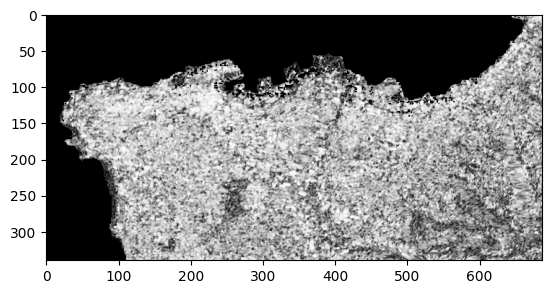

Post-event Coherence map


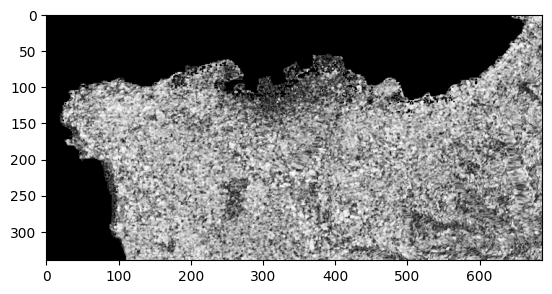

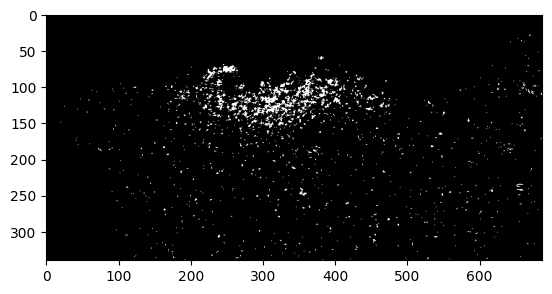

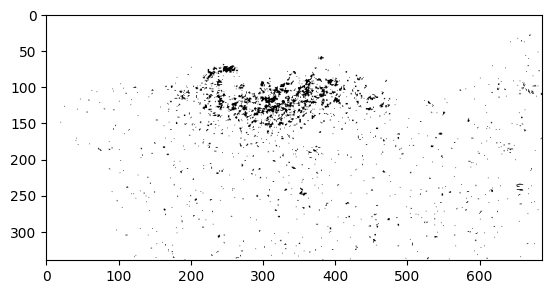


new profile: {'blockxsize': 687,
 'blockysize': 3,
 'count': 3,
 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'),
 'driver': 'GTiff',
 'dtype': 'uint8',
 'height': 340,
 'interleave': 'pixel',
 'nodata': 0.0,
 'tiled': False,
 'transform': Affine(0.0001796630568239043, 0.0, 35.46361579784938,
       0.0, -0.0001796630568239043, 33.919623834379344),
 'width': 687}



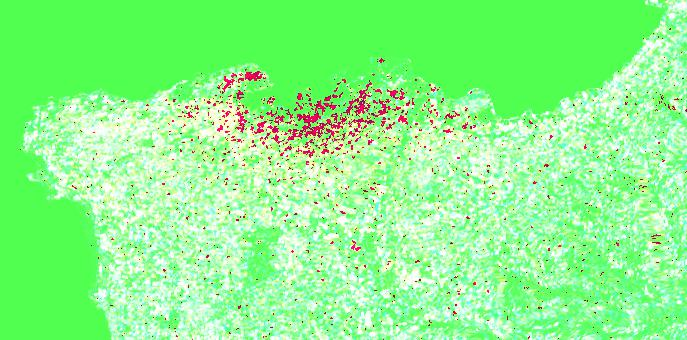

In [58]:
#@title Computing the Coherence change detection using SNAP outputs
try:
  import rasterio as rio
except:
  !pip install rasterio
  import rasterio as rio
from matplotlib import pyplot
import glob
import os

print('Define a coherence change threshold [0,1] :')
print('Suggested threshold=0.4')
threshold=input()

images=sorted(glob.glob(os.path.join(os.getcwd(),'*tif')))
print(images)
# Reading and plotting pre-event Coherence
print('Pre-event Coherence map')
with rio.open(images[0]) as src:
  coh1=src.read(1)
  pyplot.imshow(src.read(1), cmap='gray')
  pyplot.show()
# Reading and plotting post-event Coherence
print('Post-event Coherence map')
with rio.open(images[1]) as src2:
  transform=src2.transform
  crs=src2.crs
  profile=src2.profile
  coh2=src2.read(1)
  pyplot.imshow(src2.read(1), cmap='gray')
  pyplot.show()


## Composing the RGB image for visual comparison
import numpy as np
channels=np.empty([3,coh1.shape[0],coh1.shape[1]],dtype=np.uint8)
from skimage import  img_as_ubyte
from skimage import exposure

diff=(coh1-coh2)>float(threshold)
pyplot.imshow(diff, cmap='gray')
pyplot.show()

diff=1-diff
pyplot.imshow(diff, cmap='gray')
pyplot.show()

for index,image in enumerate([coh1,diff,coh2]):
    stretched=exposure.equalize_hist(image)
    channels[index,:,:] = img_as_ubyte(stretched)

tif_filename = os.path.join(os.getcwd(),'Bata_CCC.tif')
num_chans, height, width = channels.shape
with rio.open(tif_filename,'w',driver='GTiff',
                   height=height,width=width,
                   count=num_chans,dtype=channels.dtype,
                   crs=crs,transform=transform, nodata=0.0) as dst:
        dst.write(channels)

import pprint
# Plotting RGB
with rio.open(tif_filename) as infile:
    print(f"\nnew profile: {pprint.pformat(infile.profile)}\n")
    profile=infile.profile
    #
    # change the driver name from GTiff to PNG
    #
    profile['driver']='PNG'
    #
    # pathlib makes it easy to add a new suffix to a
    # filename
    #
    png_filename=tif_filename.split('.')[0]+'.png'
    raster=infile.read()
    with rio.open(png_filename, 'w', **profile) as dst:
        dst.write(raster)
    #
    # now do jpeg
    #
    profile['driver']='JPEG'
    jpeg_filename=tif_filename.split('.')[0]+'.jpeg'
    with rio.open(jpeg_filename, 'w', **profile) as dst:
        dst.write(raster)

from IPython.display import Image
Image(str(jpeg_filename))

# Visualising the results in map

In [59]:
#@title importing libraries to plot maps
import folium
from folium import plugins
#from scipy.ndimage import imread
import glob

In [60]:
#@title Defining function to create browse images
# function definition of quicklook generation
from datetime import datetime
import time
from subprocess import Popen,PIPE,STDOUT

def quicklook_gen(image): #,colormap):
    now = datetime.now()
    tmpfolder=os.getcwd()
    cmd=['./snap/bin/pconvert','-b','1',image,'-f','png','-o',tmpfolder]
    print('#########################')
    print('Creating browse image')
    timeStarted = time.time()
    process = Popen(cmd, stdout=PIPE, stderr=STDOUT)
    r = b""
    for line in process.stdout:
        r += line
        print(str(line))
    process.wait()
    timeDelta = time.time() - timeStarted                     # Get execution time.
    print('Finished process in '+str(timeDelta)+' seconds.')
    if process.returncode != 0 :
        message='Error creating browse image'
    else:
        message='Browse image successfully completed.'
        print( message)

In [61]:
#@title Creating browse images to plot in map
images=glob.glob(os.path.join(os.getcwd(),'2*.tif'))
print(images)
for file in images:
    print('Generating quicklook of file:'+file)
    quicklook_gen(file)#,None)

['/content/20200730_20200805_IW1.tif', '/content/20200730_20200724_IW1.tif']
Generating quicklook of file:/content/20200730_20200805_IW1.tif
#########################
Creating browse image
b'INFO: org.esa.snap.core.gpf.operators.tooladapter.ToolAdapterIO: Initializing external tool adapters\n'
b'INFO: org.esa.snap.core.util.EngineVersionCheckActivator: Please check regularly for new updates for the best SNAP experience.\n'
b'reading file /content/20200730_20200805_IW1.tif\n'
b"creating histogram for band 'coh_IW1_VV_30Jul2020_05Aug2020'...\n"
b'creating RGB image...\n'
b"writing RGB image to '/content/20200730_20200805_IW1.png'...\n"
Finished process in 14.635788917541504 seconds.
Browse image successfully completed.
Generating quicklook of file:/content/20200730_20200724_IW1.tif
#########################
Creating browse image
b'INFO: org.esa.snap.core.gpf.operators.tooladapter.ToolAdapterIO: Initializing external tool adapters\n'
b'INFO: org.esa.snap.core.util.EngineVersionCheckActiva

In [62]:
#@title Defining mapping visualisation functions
def visualising(images,tag_names):
    file=images[0]
    print(file[:-4]+'.tif')
    src=rio.open(file[:-4]+'.tif')
    BBOX=src.bounds
    print(BBOX)
    ymin=BBOX[1]
    xmin=BBOX[0]
    ymax=BBOX[3]
    xmax=BBOX[2]
    ymean=(ymax+ymin)/2
    xmean=(xmax+xmin)/2

    #m = folium.Map([ymean, xmean], zoom_start=20, tiles='stamenterrain',crs='EPSG3857')
    token = 'pk.eyJ1Ijoiam9zZW1hbnVlbGRlbGdhZG9ibGFzY28iLCJhIjoiY2tjdGxkcGMzMGZqMjJzbnRzN3hzZGFpNSJ9.OAiDxye2w6didAUn2DnJRw'
    # your mapbox token
    tileurl = 'https://api.mapbox.com/v4/mapbox.satellite/{z}/{x}/{y}@2x.png?access_token=' + str(token)

    #m = folium.Map(location=[ymean, xmean], zoom_start=15, tiles=tileurl, attr='Mapbox')
    m = folium.Map(location=[ymean, xmean], zoom_start=13, tiles=None)
    #m = folium.Map((0, 0), tiles=None)
    folium.TileLayer(tileurl, name='myMapbox',attr='Mapbox').add_to(m)

    #m = folium.Map(location=[ymean, xmean], zoom_start=15, tiles=tileurl, attr='Mapbox')
    #merc = os.path.join(file)
    k=0
    for merc in images:
        if not os.path.isfile(merc):
            print(f'Could not find {merc}')
        else:
            img = folium.raster_layers.ImageOverlay(
                name=tag_names[k],
        #        image=band,
                image=merc,
                bounds=[[ymin, xmin], [ymax, xmax]],
                opacity=0.6,
                interactive=True,
                cross_origin=False,
                zindex=1,
            )
            img.add_to(m)
        k=k+1
    #jsonfile='/content/drive/MyDrive/WB_Coherence/Tapovan/Tapovan_Dam.geojson'

    #gjson = folium.GeoJson(jsonfile,name='Tapovan Dam').add_to(m)

    folium.LayerControl().add_to(m)
    m.save(os.path.join(os.getcwd(), 'SNAP_S1_CCC_Bata.html'))
    return m

['/content/20200730_20200724_IW1.png', '/content/20200730_20200805_IW1.png', '/content/Bata_CCC.png']
/content/20200730_20200724_IW1.tif
BoundingBox(left=35.46361579784938, bottom=33.85853839505921, right=35.587044317887404, top=33.919623834379344)



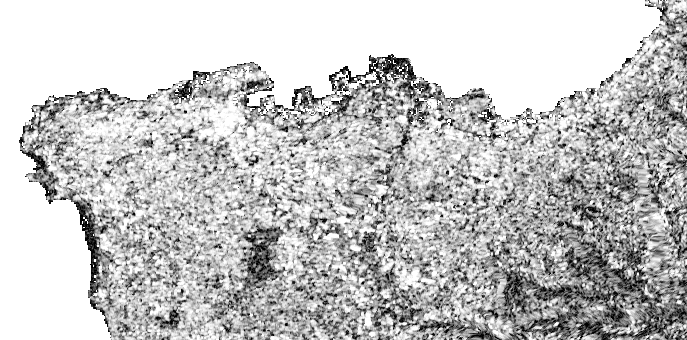
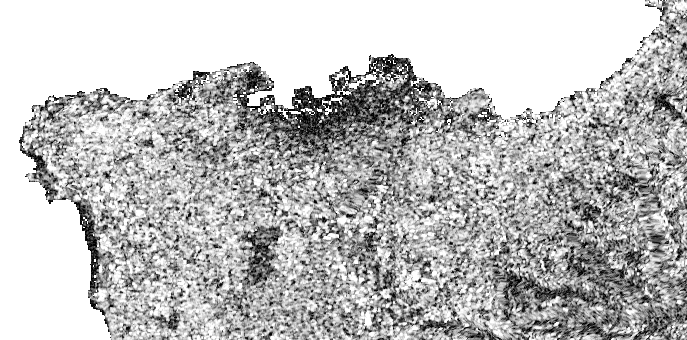
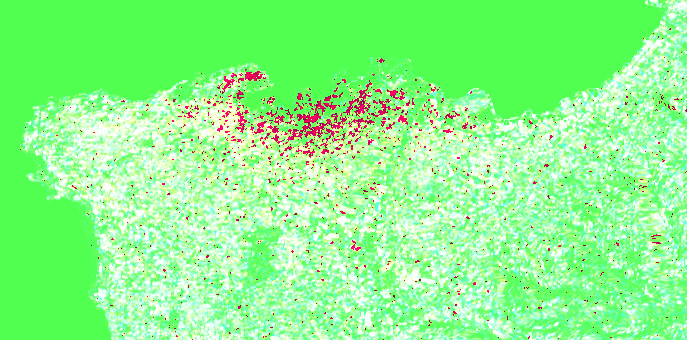

In [63]:
#@title Visualising outputs in map
import glob
import os
try:
  import rasterio as rio
except:
  !pip install rasterio
  import rasterio as rio
import folium
# Visualising images in the map
images=sorted(glob.glob(os.path.join(os.getcwd(),'*png')))
print(images)
tags=['Pre-event1','Post-event','Coherence Change']
m=visualising(images,tags)

#import pandas as pd
## Adding point to map
#id = [0]
#name = ['Tapovan dam']
#latitude = ['30.493442']
#longitude = ['79.629040']
#region = ['Uttarakhand (India)']
#df_counters = pd.DataFrame(
#    {'ID' : id,
#     'Name' : name,
#     'latitude' : latitude,
#     'longitude' : longitude,
#     'region' : region
#    })
#df_counters.head()
#locations = df_counters[['latitude', 'longitude']]
#locationlist = locations.values.tolist()
#print(len(locationlist))
#print(locationlist[0])

#folium.Marker([30.493442, 79.629040], popup='Tapovan Dam\n'+'Uttarakhand (India)').add_to(m)

m

# Downloading results locally

In [ ]:
#@title Downloading results (tif,png and html) in local computer
print('Zipping and downloading tif,png and html files')
!rm /content/*zip /content/*sh
from google.colab import files
!zip /content/CCC_colab_results.zip /content/*.tif /content/*.png /content/*.html
files.download('/content/CCC_colab_results.zip')

# Saving results to Google Drive

In [ ]:
#@title Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
#@title Uploading files to Google Drive
import glob
import shutil
try:
  from tqdm.notebook import tqdm, trange
except:
  !pip install tqdm
  from tqdm.notebook import tqdm, trange
print('Total files to copy: '+str(len(os.listdir('/content/'))))
filelist=sorted(os.listdir('/content/'))
print(filelist)
for _ in trange(len(filelist),desc='Copying files'):
  if os.path.isfile(filelist[_]):
    shutil.copy(filelist[_], '/content/drive/MyDrive/WB_Coherence/Bata/')
    print(filelist[_]+' successfully copied!')
